# **Project of finding survivors of a catastrophical encouter with ice**

**Firstly we of course add default libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

**Now we open the titanic data set**

In [2]:
%pip install kagglehub
import kagglehub

# Download latest version
path = kagglehub.competition_download('titanic')

print("Path to competition files:", path)

Note: you may need to restart the kernel to use updated packages.
Path to competition files: C:\Users\bakug\.cache\kagglehub\competitions\titanic


In [3]:
train=pd.read_csv(path + '/train.csv')
print(train.columns)
test=pd.read_csv(path + '/test.csv')
print(test.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')
Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [4]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**We successfully read the train and test data and now we will explore it and check for nulls and duplicates**

In [5]:
print(train.info())
print("Train duplicated sum: ",train.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
Train duplicated sum:  0


In [6]:
print(test.info())
print("Test duplicated sum: ",test.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB
None
Test duplicated sum:  0


**Basic statistics of train, test data 1-numerical(int) 2-text(object)**

In [7]:
print(train.describe())
print(test.describe())

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  
       PassengerId      Pclass         Age       SibSp       Parch        Fare
co

In [8]:
print(train.describe(include=['O']))
print(test.describe(include=['O']))

                           Name   Sex  Ticket    Cabin Embarked
count                       891   891     891      204      889
unique                      891     2     681      147        3
top     Braund, Mr. Owen Harris  male  347082  B96 B98        S
freq                          1   577       7        4      644
                    Name   Sex    Ticket            Cabin Embarked
count                418   418       418               91      418
unique               418     2       363               76        3
top     Kelly, Mr. James  male  PC 17608  B57 B59 B63 B66        S
freq                   1   266         5                3      270


**We can see that few columns have huge amount of nulls and a few columns have all unique values, so we will do something about it.**

**Columns Passenger_id and Cabin (as it is mostly nulls) won't be necessary, so we will delete it**

In [9]:
train.drop(columns=['PassengerId','Cabin'], inplace=True)
test.drop(columns=['PassengerId','Cabin'], inplace=True)
print(train.columns)
print(test.columns)

Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket',
       'Fare', 'Embarked'],
      dtype='object')
Index(['Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare',
       'Embarked'],
      dtype='object')


**Now we have to do something about nulls in age, fare and embarked columns**

**We will fill nulls with median of age**

In [10]:
train['Age'].fillna(train['Age'].median(), inplace=True)
test['Age'].fillna(test['Age'].median(), inplace=True)

C:\Users\bakug\AppData\Local\Temp\ipykernel_24732\3278935906.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['Age'].fillna(train['Age'].median(), inplace=True)
C:\Users\bakug\AppData\Local\Temp\ipykernel_24732\3278935906.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.


In [11]:
print(train.isnull().sum())
print(test.isnull().sum())

Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Embarked    2
dtype: int64
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        1
Embarked    0
dtype: int64


**Fare null in test data**

In [12]:
test.fillna(test["Fare"].median(), inplace=True)
print(test.isnull().sum())

Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Embarked    0
dtype: int64


**Embarked nulls in train data**

In [13]:
train["Embarked"].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

**As there are mostly embarked in Southampton we will fill the nulls with value S**

In [14]:
train.fillna(train["Embarked"].mode()[0], inplace=True)
print(train["Embarked"].value_counts())

Embarked
S    646
C    168
Q     77
Name: count, dtype: int64


**Now we will visiualize how different colums affect survival rate**

**Age to Survived**

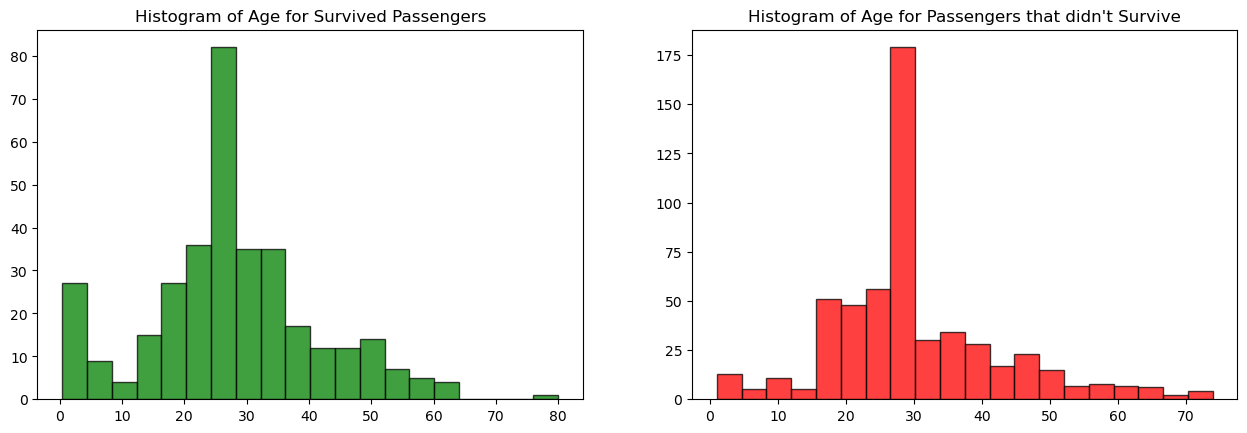

In [15]:
fig, axes = plt.subplots(nrows=1, ncols=2)
axes[0].hist(
    train.loc[train['Survived'] == 1, 'Age'].dropna(),
    bins=20,
    color='green',
    edgecolor='black',
    alpha=0.75,
)
axes[1].hist(
    train.loc[train['Survived'] == 0, 'Age'].dropna(),
    bins=20,
    color='red',
    edgecolor='black',
    alpha=0.75,
)

axes[1].set_title('Histogram of Age for Passengers that didn\'t Survive')
axes[0].set_title('Histogram of Age for Survived Passengers')
plt.subplots_adjust(right=2)
plt.show()

**We can observe that highest survival rate is for children below age 10 and that most people over the age of 65 didn't survive.**

**Pclass to survived (1st - highest class, 3rd - lowest class)**

Pclass
1    136
2     87
3    119
Name: Survived, dtype: int64
Pclass
1    216
2    184
3    491
Name: Survived, dtype: int64


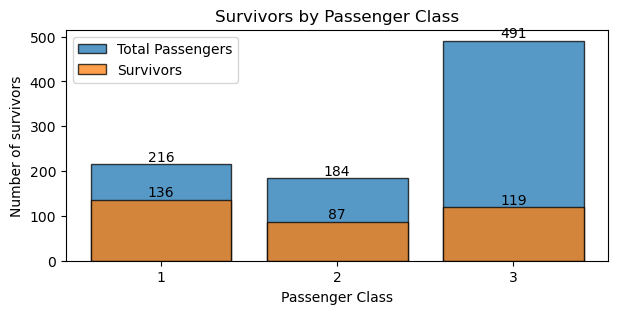

In [16]:
plt.figure(figsize=(7, 3))
surv_per_class = train.groupby('Pclass')['Survived'].sum()
all_per_class = train.groupby('Pclass')['Survived'].count()
print(surv_per_class)
print(all_per_class)

for index, value in surv_per_class.items():
    plt.text(index, value, f'{value}', ha='center', va='bottom')

for index, value in all_per_class.items():
    plt.text(index, value, f'{value}', ha='center', va='bottom')

plt.bar(surv_per_class.index, all_per_class.values, edgecolor='black', alpha=0.75, label='Total Passengers')
plt.bar(surv_per_class.index, surv_per_class.values, edgecolor='black', alpha=0.75, label='Survivors')
plt.xlabel('Passenger Class')
plt.ylabel('Number of survivors')
plt.xticks(surv_per_class.index)
plt.title('Survivors by Passenger Class')
plt.legend()
plt.show()

**We see that most amount of people that survived compared to the quantity of all people in the corresponding class is biggest in first class**

**We continue checking different columns, now sex**

Sex
female    233
male      109
Name: Survived, dtype: int64
Sex
female    314
male      577
Name: Survived, dtype: int64


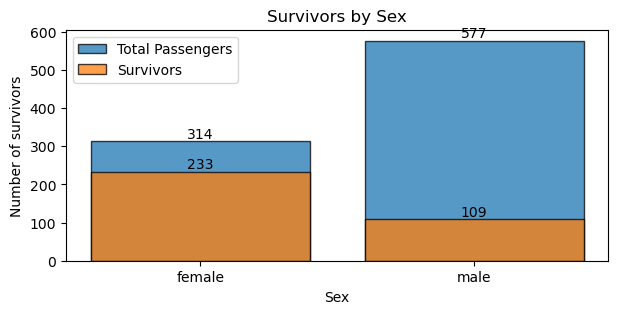

In [17]:
sex_by_surv=train.groupby('Sex')['Survived'].sum()
sex_by_total=train.groupby('Sex')['Survived'].count()
print(sex_by_surv)
print(sex_by_total)

plt.figure(figsize=(7, 3))

for index, value in sex_by_surv.items():
    plt.text(index, value, f'{value}', ha='center', va='bottom')

for index, value in sex_by_total.items():
    plt.text(index, value, f'{value}', ha='center', va='bottom')

plt.bar(sex_by_surv.index, sex_by_total.values, edgecolor='black', alpha=0.75, label='Total Passengers')
plt.bar(sex_by_surv.index, sex_by_surv.values, edgecolor='black', alpha=0.75, label='Survivors')
plt.xlabel('Sex')
plt.ylabel('Number of survivors')
plt.xticks(sex_by_surv.index)
plt.title('Survivors by Sex')
plt.legend()
plt.show()

**So most survived people are women**

**Now we will quickly see how the remaining columns compare to the survival rate**

**Embarked**

In [20]:
emb_count = train["Survived"].groupby(train['Embarked']).value_counts()
print(emb_count)

Embarked  Survived
C         1            93
          0            75
Q         0            47
          1            30
S         0           427
          1           219
Name: count, dtype: int64


**As we can see most of the people embarked in Chersburg survive, while the ones from other embarked cities didn't**

**Siblings/spouses**

In [21]:
sib_spo = train["Survived"].groupby(train['SibSp']).value_counts()
print(sib_spo)

SibSp  Survived
0      0           398
       1           210
1      1           112
       0            97
2      0            15
       1            13
3      0            12
       1             4
4      0            15
       1             3
5      0             5
8      0             7
Name: count, dtype: int64
